In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)



# Load & Data Understanding

In [122]:
df = pd.read_csv('loan_data.csv')
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [124]:
df.describe(include='all')

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


In [125]:
df.duplicated().sum()

np.int64(0)

In [126]:
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [127]:
print(df["loan_status"].value_counts())
print()
print(df["loan_status"].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

loan_status
0    35000
1    10000
Name: count, dtype: int64

loan_status
0    77.78 %
1    22.22 %
Name: proportion, dtype: str


In [128]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


person_gender
<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

person_education
<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str

person_home_ownership
<ArrowStringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

loan_intent
<ArrowStringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

previous_loan_defaults_on_file
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


C:\Users\Hp\AppData\Local\Temp\ipykernel_23920\3025381906.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


### Feature Description

| Feature | Description | Expected Type |
|---|---|---|
| `person_age` | Applicant age | Numerical |
| `person_income` | Applicant income | Numerical |
| `person_emp_exp` | Employment experience | Numerical |
| `loan_amnt` | Requested loan amount | Numerical |
| `loan_int_rate` | Loan interest rate | Numerical |
| `loan_percent_income` | Loan amount relative to income | Numerical |
| `cb_person_cred_hist_length` | Credit history length | Numerical |
| `credit_score` | Applicant credit score | Numerical |
| `person_gender` | Applicant gender | Categorical |
| `person_education` | Applicant education level | Categorical |
| `person_home_ownership` | Home ownership status | Categorical |
| `loan_intent` | Purpose of the loan | Categorical |
| `previous_loan_defaults_on_file` | Previous loan default status | Categorical |
| `loan_status` | Loan approval outcome | Target |

# Data Cleaning

In [129]:
print(f'Ages over 100: {(df["person_age"] > 100).sum()}')
df[df["person_age"] >= 100]

Ages over 100: 7


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
81,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,No,0
183,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,No,0
575,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,Yes,0
747,123.0,male,Bachelor,94723.0,100,RENT,20000.0,VENTURE,11.01,0.21,4.0,714,Yes,0
32297,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,No,0
37930,116.0,male,Bachelor,5545545.0,93,MORTGAGE,3823.0,VENTURE,12.15,0.00,24.0,708,No,0
38113,109.0,male,High School,5556399.0,85,MORTGAGE,6195.0,VENTURE,12.58,0.00,22.0,792,No,0


In [130]:
rows_before = len(df)

df_clean = df[(df.person_age <= 90) & (df.person_income <= 1_000_000)].copy()

print(f"Rows removed: {rows_before - len(df_clean)}")
print(f"Remaining rows: {len(df_clean)}")

print("\nTarget distribution after cleaning:")
print(df_clean.loan_status.value_counts(normalize=True).mul(100).round(2))


Rows removed: 29
Remaining rows: 44971

Target distribution after cleaning:
loan_status
0    77.76
1    22.24
Name: proportion, dtype: float64


# EDA

In [131]:
df=df_clean.copy()

In [132]:
numeric_col=df.select_dtypes(include='number').columns
categrical_col=df.select_dtypes(include=['str','object']).columns
numeric_col

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='str')

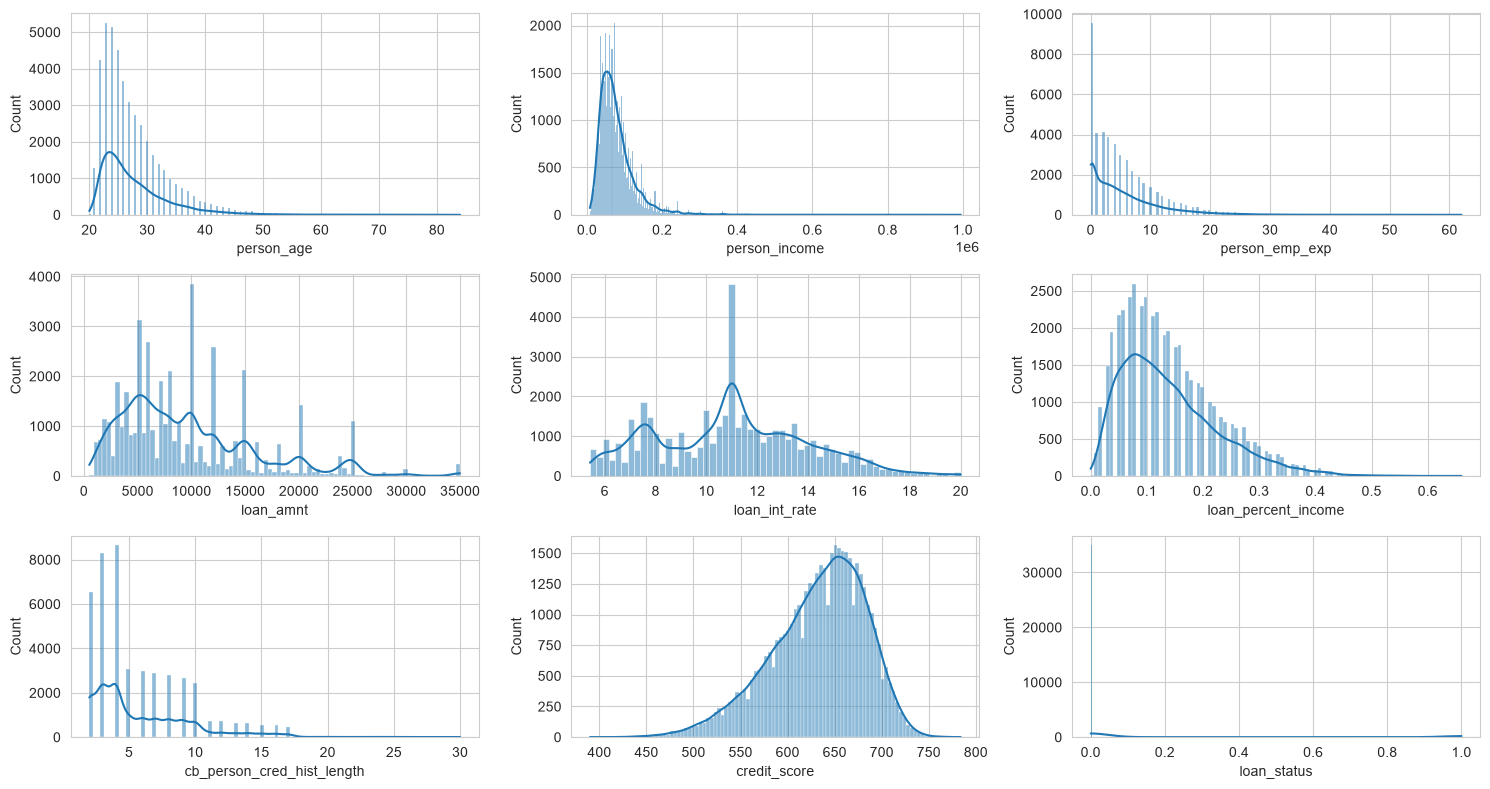

In [133]:
# Plot distributions of numerical features
fig, ax = plt.subplots(3,3, figsize=(15,8))

i = 0
j = 0
for var in df[numeric_col]:
    sns.histplot(df,x=var,ax=ax[i,j],kde=True)
    if j==2:
        j=0
        i+=1
    else:
        j+=1

plt.tight_layout()
plt.show()

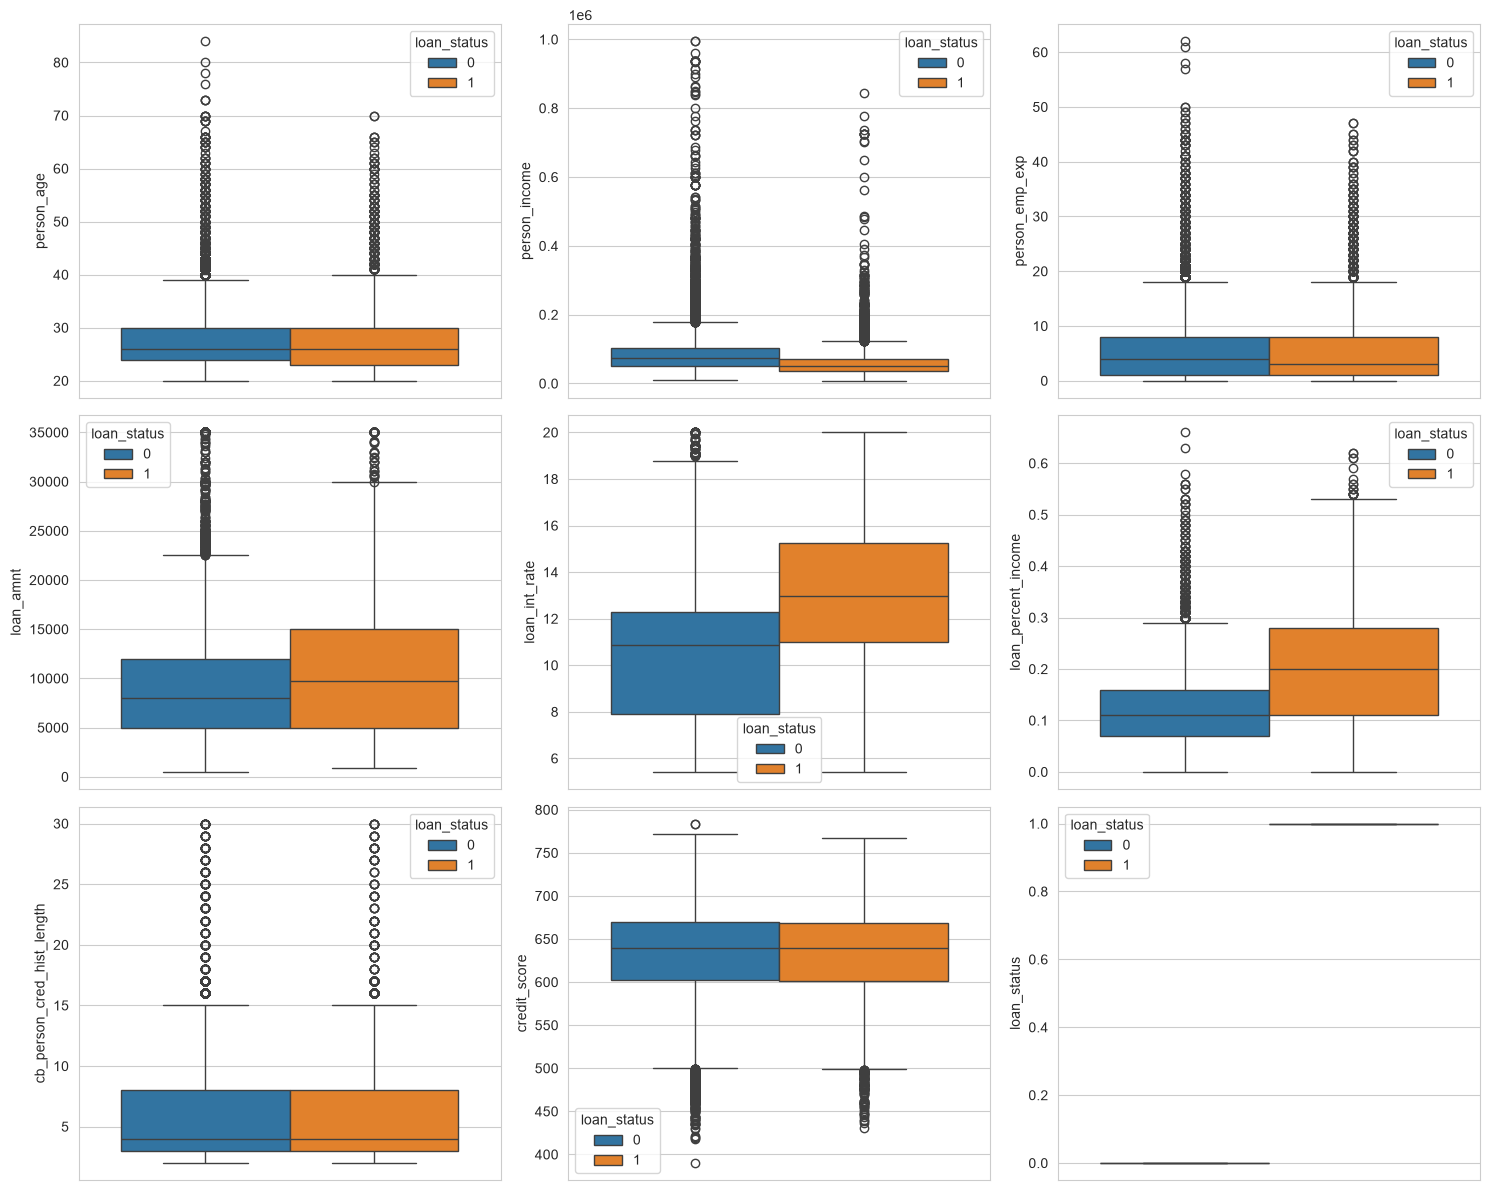

In [134]:
# Plot Boxplot of numerical features
fig, ax = plt.subplots(3,3, figsize=(15,12))

i = 0
j = 0
for var in df[numeric_col]:
    sns.boxplot(df,y=var,hue=df['loan_status'],ax=ax[i,j])
    if j==2:
        j=0
        i+=1
    else:
        j+=1

plt.tight_layout()
plt.show()

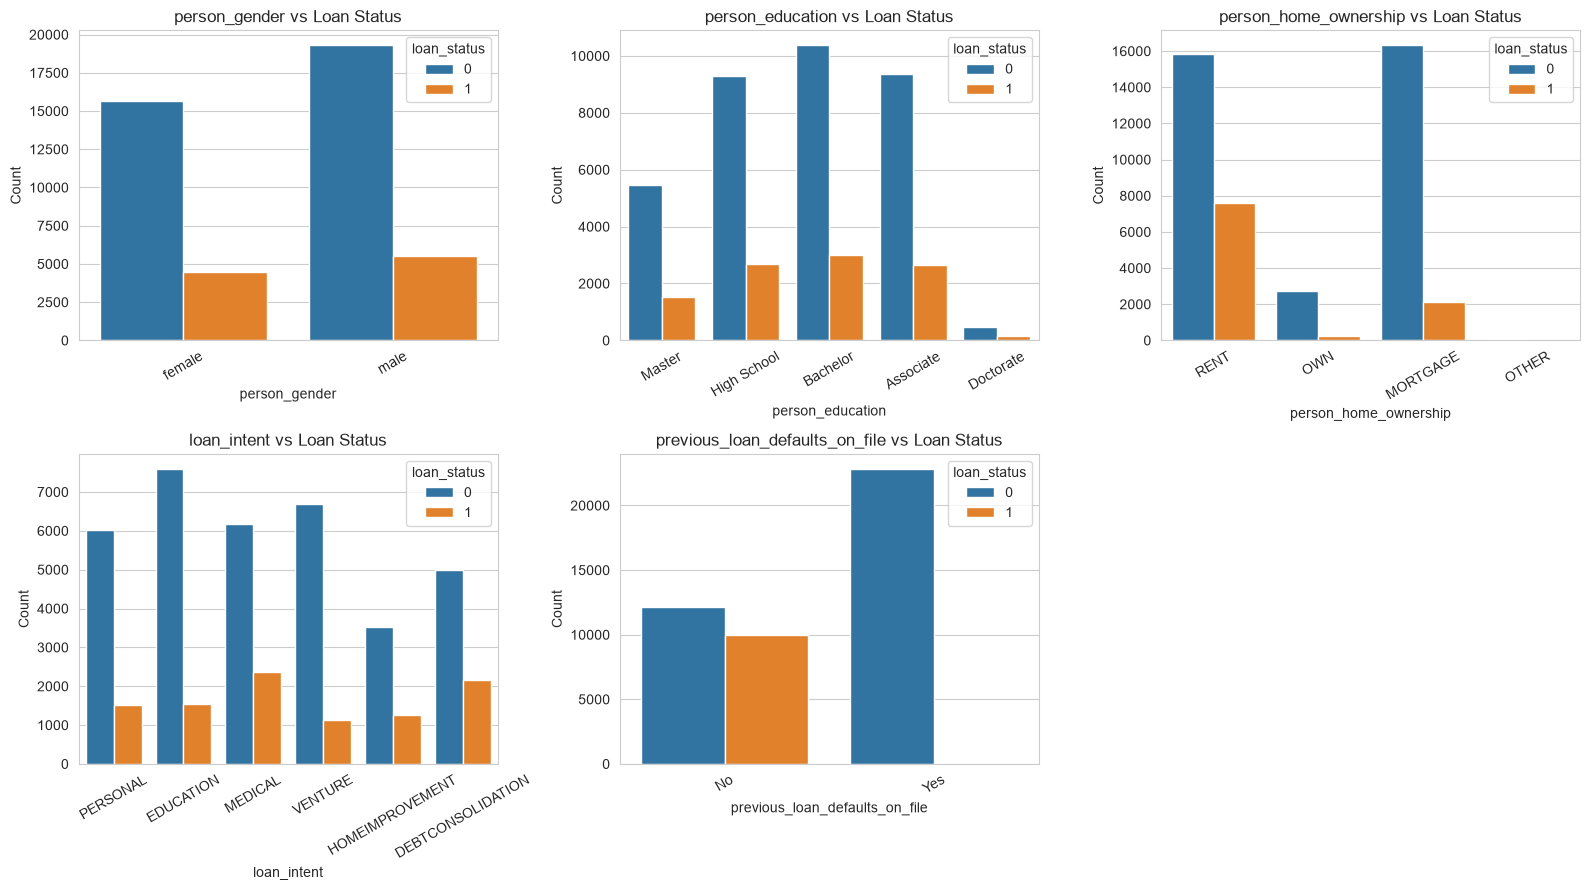

In [135]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        hue="loan_status",
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs Loan Status")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

# Remove the empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# Data Analysis &amp; Insights

### Q1 — How imbalanced is the target, exactly?


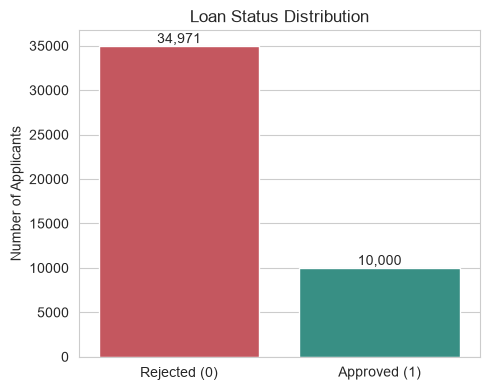

In [136]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df_clean, x="loan_status", hue="loan_status",
                    palette=["#d64550", "#2a9d8f"], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Rejected (0)", "Approved (1)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.title("Loan Status Distribution")
plt.xlabel("")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

**Insight:** ~78% rejected vs ~22% approved. Any model will need class-balancing
(e.g. `class_weight`, resampling) and should be judged on F1/recall/ROC-AUC, not
accuracy — a model that always predicts "rejected" would already score 78% accuracy.

### Q2 — Does a previous default predict rejection?

previous_loan_defaults_on_file
No     45.2
Yes     0.0
Name: loan_status, dtype: float64


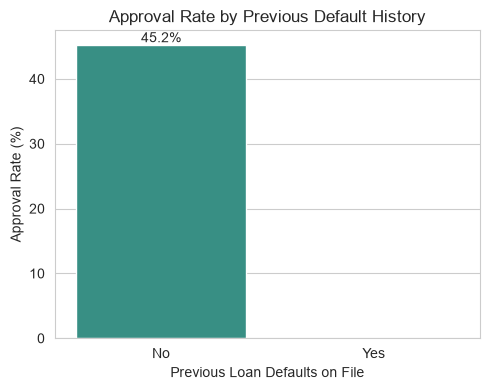

In [137]:
default_rate = (
    df_clean.groupby("previous_loan_defaults_on_file")["loan_status"]
    .mean().mul(100).round(1)
)
print(default_rate)

plt.figure(figsize=(5, 4))
ax = sns.barplot(x=default_rate.index, y=default_rate.values,
                  hue=default_rate.index, palette=["#2a9d8f", "#d64550"], legend=False)
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.title("Approval Rate by Previous Default History")
plt.xlabel("Previous Loan Defaults on File")
plt.ylabel("Approval Rate (%)")
plt.tight_layout()
plt.show()

**Insight:** Applicants with **no** prior default history are approved at a much
higher rate than those with one on file. This is very likely to be the single most
important feature for the model.

### Q3 — Is debt burden (loan as % of income) different between approved and rejected applicants?

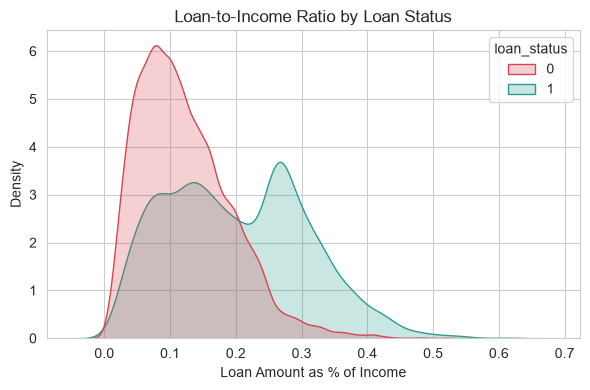

In [138]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_clean, x="loan_percent_income", hue="loan_status",
            fill=True, common_norm=False, palette=["#d64550", "#2a9d8f"])
plt.title("Loan-to-Income Ratio by Loan Status")
plt.xlabel("Loan Amount as % of Income")
plt.tight_layout()
plt.show()

**Insight:** Rejected applications cluster at higher loan-to-income ratios than
approved ones. Borrowers asking for a loan that represents a large share of their
income are riskier and get turned down more often — this matches real underwriting
logic (debt-to-income ratio).

### Q4 — Does the assigned interest rate differ by outcome?


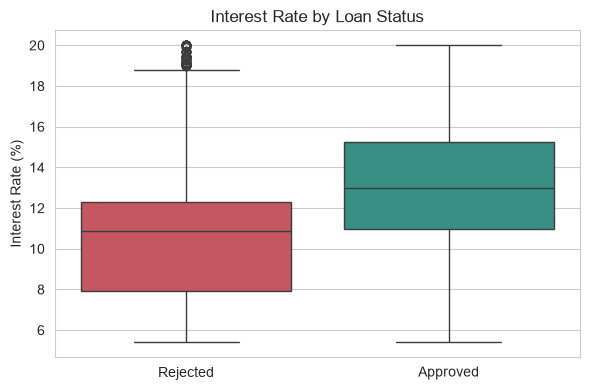

In [139]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean, x="loan_status", y="loan_int_rate",
            hue="loan_status", palette=["#d64550", "#2a9d8f"], legend=False)
plt.xticks([0, 1], ["Rejected", "Approved"])
plt.title("Interest Rate by Loan Status")
plt.xlabel("")
plt.ylabel("Interest Rate (%)")
plt.tight_layout()
plt.show()

**Insight:** Approved loans tend to carry a *lower* interest rate than rejected
ones. This makes sense if the interest rate is itself a proxy for risk assigned at
application time — high-risk applicants get quoted higher rates and are also more
likely to be rejected.

### Q5 — Does home ownership status relate to approval?


person_home_ownership
OTHER       33.3
RENT        32.4
MORTGAGE    11.6
OWN          7.5
Name: loan_status, dtype: float64


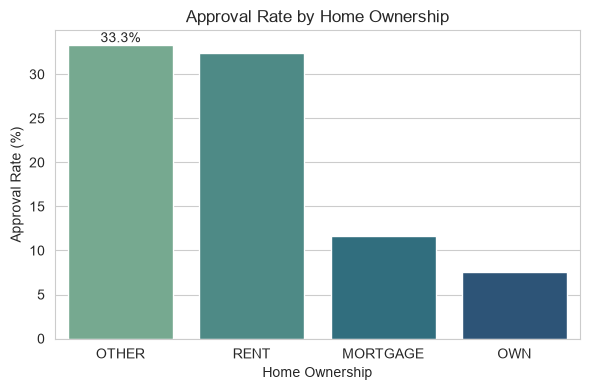

In [140]:
home_rate = (
    df_clean.groupby("person_home_ownership")["loan_status"]
    .mean().mul(100).round(1).sort_values(ascending=False)
)
print(home_rate)

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=home_rate.index, y=home_rate.values,
                  hue=home_rate.index, palette="crest", legend=False)
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.title("Approval Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Approval Rate (%)")
plt.tight_layout()
plt.show()

**Insight:** Renters are approved noticeably more often than mortgage holders
or homeowners in this dataset — likely because renters in this data skew toward
smaller, more serviceable loan requests relative to income, while `OTHER` is a small,
noisy category.

### Q6 — Are the numeric features correlated with each other (and worth all keeping)?


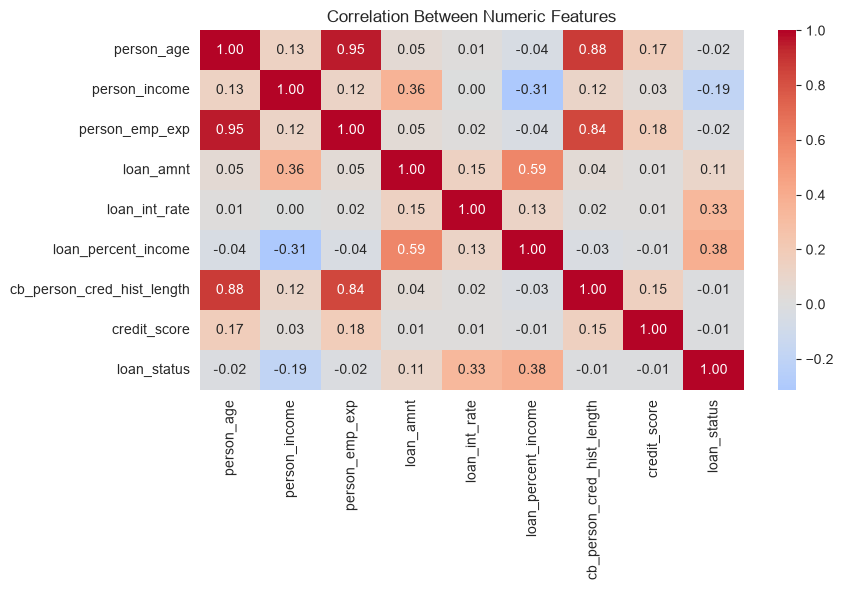

In [141]:
plt.figure(figsize=(9, 6))
corr = df_clean[numeric_col].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

**Insight:** `person_age`, `person_emp_exp`, and `cb_person_cred_hist_length` are
all strongly correlated with each other (older applicants naturally have more work
experience and longer credit histories). This is useful to know for Logistic
Regression / linear models, but tree-based models (Random Forest, final_PipelineBoost) handle
correlated features natively, so I won't drop anything here — just keep it in mind
when interpreting coefficients later.

# Split the Data

In [145]:
from sklearn.model_selection import train_test_split

X=df.drop('loan_status',axis=1)
y=df['loan_status']


X_train_val, X_test,y_train_val,y_test = train_test_split(X,y,test_size=0.15,random_state=42,shuffle=True)

X_train,X_val,y_train,y_val = train_test_split(X_train_val,y_train_val,random_state=42,test_size=0.1765)

print(f"Train size: {len(X_train)/len(X):.2%}")  # ~70%
print(f"Val size:   {len(X_val)/len(X):.2%}")    # ~15%
print(f"Test size:  {len(X_test)/len(X):.2%}")   # ~15%


X_train_org = X_train.copy()
X_val_org =X_val.copy()
X_test_org= X_test.copy()


y_train_org = y_train.copy()
y_val_org =y_val.copy()
y_test_org= y_test.copy()

Train size: 70.00%
Val size:   15.00%
Test size:  15.00%


# Data Preprocessing

In [146]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


person_gender
<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

person_education
<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str

person_home_ownership
<ArrowStringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

loan_intent
<ArrowStringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

previous_loan_defaults_on_file
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


## Encoding

In [147]:
from sklearn.preprocessing import OneHotEncoder
ohn= OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')

X_train_enode= ohn.fit_transform(X_train[['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']])
X_val_enode= ohn.transform(X_val[['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']])
X_test_enode= ohn.transform(X_test[['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']])

X_train_enode=pd.DataFrame(X_train_enode,columns=ohn.get_feature_names_out(['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']),index=X_train.index)
X_val_enode=pd.DataFrame(X_val_enode,columns=ohn.get_feature_names_out(['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']),index=X_val.index)
X_test_enode=pd.DataFrame(X_test_enode,columns=ohn.get_feature_names_out(['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']),index=X_test.index)



X_train=pd.concat([X_train.drop(columns=['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']),X_train_enode],axis=1)
X_val=pd.concat([X_val.drop(columns=['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']),X_val_enode],axis=1)
X_test=pd.concat([X_test.drop(columns=['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']),X_test_enode],axis=1)



,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
33312,27.0,45958.0,1,8000.0,12.67,0.17,6.0,564,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
37369,27.0,43273.0,3,5000.0,12.61,0.12,5.0,672,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
507,22.0,23497.0,0,3625.0,8.49,0.15,3.0,557,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
54,25.0,144985.0,3,30000.0,7.90,0.21,4.0,559,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
29428,44.0,33180.0,22,6200.0,6.03,0.19,16.0,691,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31698,36.0,149994.0,13,2000.0,12.99,0.01,16.0,685,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43139,28.0,59688.0,6,12000.0,14.49,0.20,5.0,714,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
21660,28.0,52730.0,8,6000.0,10.39,0.11,5.0,620,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4963,22.0,52541.0,1,2600.0,11.01,0.05,4.0,617,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


## Scaling

In [148]:
from sklearn.preprocessing import RobustScaler
scaler= RobustScaler()

X_train = scaler.fit_transform(X_train)
X_train= pd.DataFrame(X_train,columns=X_val.columns,index=y_train.index)

X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

X_val = pd.DataFrame(X_val,columns=X_train.columns,index=y_val.index)
X_test = pd.DataFrame(X_test,columns=X_train.columns,index=y_test.index)

# Building Model

In [151]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
)

results = {}

def evaluate_classifier(name, model, X_te, y_te, y_pred, y_proba=None):
    '''Compute and store the standard classification metrics for one trained model.'''
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "ROC-AUC": auc}

    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if y_proba is not None:
        print(f"ROC-AUC:   {auc:.4f}")
    print()
    return results[name]

In [153]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression

logr =  LogisticRegression(max_iter=10000,random_state=42)

logr.fit(X_train,y_train)
y_pred= logr.predict(X_val)
y_proba = logr.predict_proba(X_val)[:,1]

evaluate_classifier('LogisticRegression',logr,X_val,y_val,y_pred,y_proba)

--- LogisticRegression ---
Accuracy:  0.8955
Precision: 0.7829
Recall:    0.7498
F1-Score:  0.7660
ROC-AUC:   0.9553



{'Accuracy': 0.8955091151622944,
 'Precision': 0.7829036635006784,
 'Recall': 0.7498375568551007,
 'F1-Score': 0.7660139395950879,
 'ROC-AUC': 0.9552572690188235}

In [154]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)
y_pred= knn.predict(X_val)
y_proba= knn.predict_proba(X_val)[:,1]

evaluate_classifier("Knn (k=5)",knn,X_val,y_val,y_pred,y_proba) 

--- Knn (k=5) ---
Accuracy:  0.8936
Precision: 0.8084
Recall:    0.6992
F1-Score:  0.7498
ROC-AUC:   0.9293



{'Accuracy': 0.8935823328886913,
 'Precision': 0.8084147257700977,
 'Recall': 0.6991552956465237,
 'F1-Score': 0.7498257839721254,
 'ROC-AUC': 0.9292976816793077}

In [155]:
from sklearn.ensemble import RandomForestClassifier


rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_val)
y_proba = rf_clf.predict_proba(X_val)[:, 1]

evaluate_classifier("Random Forest", rf_clf, X_val, y_val, y_pred, y_proba)

--- Random Forest ---
Accuracy:  0.9263
Precision: 0.8871
Recall:    0.7758
F1-Score:  0.8277
ROC-AUC:   0.9732



{'Accuracy': 0.9263376315399436,
 'Precision': 0.8870728083209509,
 'Recall': 0.7758284600389863,
 'F1-Score': 0.8277296360485269,
 'ROC-AUC': 0.9731786031187087}

In [156]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

xg= XGBClassifier(random_state=42)
xg.fit(X_train,y_train)

y_pred = xg.predict(X_val)
y_proba = xg.predict_proba(X_val)[:, 1]

evaluate_classifier("XGBoost", xg, X_val, y_val, y_pred, y_proba)

--- XGBoost ---
Accuracy:  0.9309
Precision: 0.8857
Recall:    0.8005
F1-Score:  0.8410
ROC-AUC:   0.9780



{'Accuracy': 0.9309322661923818,
 'Precision': 0.8856937455068297,
 'Recall': 0.8005198180636777,
 'F1-Score': 0.8409556313993174,
 'ROC-AUC': 0.9780326213782166}

In [157]:
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train,y_train)

y_pred = lgbm.predict(X_val)
y_proba = lgbm.predict_proba(X_val)[:, 1]

evaluate_classifier("Lightgbm", lgbm, X_val, y_val, y_pred, y_proba)

--- Lightgbm ---
Accuracy:  0.9302
Precision: 0.8831
Recall:    0.7999
F1-Score:  0.8394
ROC-AUC:   0.9774



{'Accuracy': 0.9301911960871498,
 'Precision': 0.8830703012912482,
 'Recall': 0.7998700454840806,
 'F1-Score': 0.8394135697238323,
 'ROC-AUC': 0.9774483500667239}

In [160]:
cla_results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
display(cla_results_df.style.background_gradient(cmap="Greens", subset=["Accuracy"]).format("{:.4f}"))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.9309,0.8857,0.8005,0.8410,0.9780
Lightgbm,0.9302,0.8831,0.7999,0.8394,0.9774
Random Forest,0.9263,0.8871,0.7758,0.8277,0.9732
LogisticRegression,0.8955,0.7829,0.7498,0.7660,0.9553
Knn (k=5),0.8936,0.8084,0.6992,0.7498,0.9293


# Check Overfitting for XGBoost

In [162]:
y_train_pred = xg.predict(X_train)
y_val_pred = xg.predict(X_val)

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)

train_pre = precision_score(y_train, y_train_pred)
val_pre =  precision_score(y_val,y_val_pred)

train_rec = recall_score(y_train, y_train_pred)
val_rec = recall_score(y_val, y_val_pred)

print("Training:")
print(f"Accuracy   : {train_acc:.4f}")
print(f"Precision : {train_pre:.4f}")
print(f"Recall  : {train_rec:.4f}")

print("\nValidation:")
print(f"Accuracy   : {val_acc:.4f}")
print(f"Precision : {val_pre:.4f}")
print(f"Recall  : {val_rec:.4f}")

Training:
Accuracy   : 0.9695
Precision : 0.9656
Recall  : 0.8948

Validation:
Accuracy   : 0.9309
Precision : 0.8857
Recall  : 0.8005


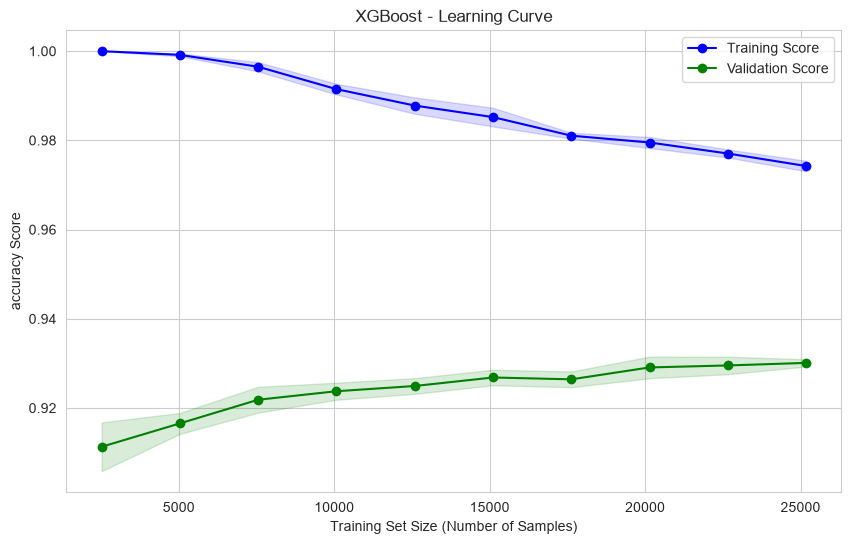

In [166]:

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X_tr, y_tr, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_tr,
        y=y_tr,
        train_sizes=np.linspace(0.1, 1.0, 10), # 10 steps from 10% to 100% data
        cv=5,                                  # Uses 5-fold CV internally
        scoring='accuracy',                          # Or 'neg_root_mean_squared_error'
        n_jobs=-1,
        random_state=42
    )

    # Calculate mean and standard deviation across folds
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    # 3. Plot the learning curves
    plt.figure(figsize=(10, 6))
    
    # Train Line
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

    # Validation Line
    plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

    plt.title(f"{title} - Learning Curve")
    plt.xlabel("Training Set Size (Number of Samples)")
    plt.ylabel("accuracy Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_learning_curve(XGBClassifier(), X_train, y_train, title="XGBoost")

# hyperparameter Tuning 

In [169]:
# import optuna
# from optuna.integration import XGBoostPruningCallback


# # Objective Function with Pruning
# def objective(trial):
#     params = {
#         "n_estimators": 1000,
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
#         "eval_metric": "logloss",
#         "early_stopping_rounds": 50,
#         "random_state": 42,
#         "n_jobs": -1,
#     }

#     # Prunes trials based on the validation set logloss at each boosting step
#     pruning_callback = XGBoostPruningCallback(trial, "validation_0-logloss")

#     model = XGBClassifier(**params, callbacks=[pruning_callback])

#     # Fit using X_train, y_train and evaluate on X_val, y_val
#     model.fit(
#         X_train,
#         y_train,
#         eval_set=[(X_val, y_val)],
#         verbose=False,
#     )

#     # Return metric evaluated on validation data
#     val_score = model.score(X_val, y_val)
#     return val_score

# # Setup Pruner and Study
# pruner = optuna.pruners.MedianPruner(
#     n_startup_trials=5, 
#     n_warmup_steps=30, 
#     interval_steps=10
# )

# study = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=pruner
# )

# # Run optimization
# study.optimize(objective, n_trials=50, timeout=600)

# # Final Training on the full training set
# best_params = study.best_params
# best_clf = XGBClassifier(**best_params, random_state=42, n_jobs=-1)
# best_clf.fit(X_train, y_train)

# print(f"Best Validation Accuracy: {study.best_value:.4f}")
# print("Best Hyperparameters:", best_params)

# #Best Validation Accuracy: 0.9346
# #Best Hyperparameters: {'max_depth': 6, 'learning_rate': 0.08970644672251804, 'subsample': 0.5560700269398415, 'colsample_bytree': 0.7635658765239728, 'min_child_weight': 5, 'gamma': 0.030417591768653867, 'reg_alpha': 0.0008849299239384577, 'reg_lambda': 1.1191776150871093e-06}

In [176]:
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBClassifier

# param_grid = {
#     "n_estimators": [300,450,500],
#     "max_depth": [ 5,6, 7],
#     "learning_rate": [0.09, 0.05, 0.1],
#     "subsample": [0.5, 0.8],
#     "colsample_bytree": [0.8, 1.0],
# }

# xgb = XGBClassifier(random_state=42, n_jobs=-1)

# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1,
#     verbose=1,
# )

# grid_search.fit(X_train, y_train)

# print(f"Best CV Score: {grid_search.best_score_:.4f}")
# print("Best Hyperparameters:", grid_search.best_params_)

# # Best CV Score: 0.9330
# # Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 450, 'subsample': 0.8}

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV Score: 0.9330
Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 450, 'subsample': 0.8}


# Final Pipeline

In [293]:
X_train =X_train_org.copy()
X_val = X_val_org.copy()
X_test= X_test_org.copy()

y_train =y_train_org.copy()
y_val = y_val_org.copy()
y_test= y_test_org.copy()


# X_train.drop('previous_loan_defaults_on_file',axis=1,inplace=True)
# X_test.drop('previous_loan_defaults_on_file',axis=1,inplace=True)
# X_val.drop('previous_loan_defaults_on_file',axis=1,inplace=True)


In [294]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

ohe_cols  = ['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
numeric_cols    = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']

preprocessor = ColumnTransformer(transformers=[
    ('ohe_encoding', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('RobustScaler',RobustScaler(),numeric_cols)
],remainder='passthrough')

final_Pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('Model',XGBClassifier(n_estimators=250,max_depth=6,colsamle_bytree=0.8,learning_rate=0.05,subsample=0.8,min_child_weight=5,gamma=0.03,reg_lambda=1.12e-06))
])
# #Best Hyperparameters: {'max_depth': 6, 'learning_rate': 0.08970644672251804, 'subsample': 0.5560700269398415, 'colsample_bytree': 0.7635658765239728, 'min_child_weight': 5, 'gamma': 0.030417591768653867, 'reg_alpha': 0.0008849299239384577, 'reg_lambda': 1.1191776150871093e-06}
final_Pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['person_age','person_gender','person_education',..., 'cb_person_cred_hist_length','credit_score', 'previous_loan_defaults_on_file']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe_encoding', ...), ('RobustScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are d

<Axes: >

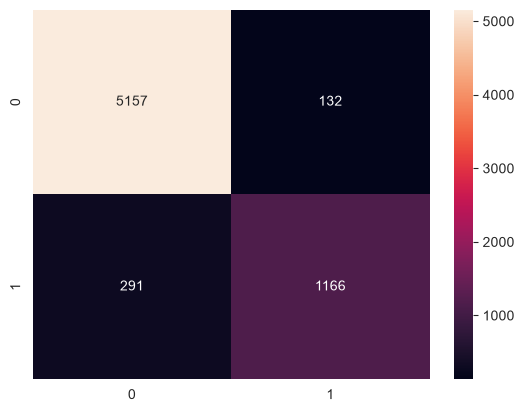

In [295]:
y_train_pred = final_Pipeline.predict(X_train)
y_val_pred = final_Pipeline.predict(X_val)
y_test_pred=final_Pipeline.predict(X_test)
y_test_proba = final_Pipeline.predict_proba(X_test)[:,1]

sns.heatmap(confusion_matrix(y_test,y_test_pred),annot=True,color='k',fmt='d')

In [296]:


# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_pre = precision_score(y_train, y_train_pred)
val_pre =  precision_score(y_val,y_val_pred)
test_pre =  precision_score(y_test,y_test_pred)

train_rec = recall_score(y_train, y_train_pred)
val_rec = recall_score(y_val, y_val_pred)
test_rec = recall_score(y_test, y_test_pred)

print("Training:")
print(f"Accuracy   : {train_acc:.4f}")
print(f"Precision : {train_pre:.4f}")
print(f"Recall  : {train_rec:.4f}")

print("\nValidation:")
print(f"Accuracy   : {val_acc:.4f}")
print(f"Precision : {val_pre:.4f}")
print(f"Recall  : {val_rec:.4f}")

print("\nTesting:")
print(f"Accuracy   : {test_acc:.4f}")
print(f"Precision : {test_pre:.4f}")
print(f"Recall  : {test_rec:.4f}")

Training:
Accuracy   : 0.9447
Precision : 0.9270
Recall  : 0.8157

Validation:
Accuracy   : 0.9297
Precision : 0.8924
Recall  : 0.7869

Testing:
Accuracy   : 0.9373
Precision : 0.8983
Recall  : 0.8003


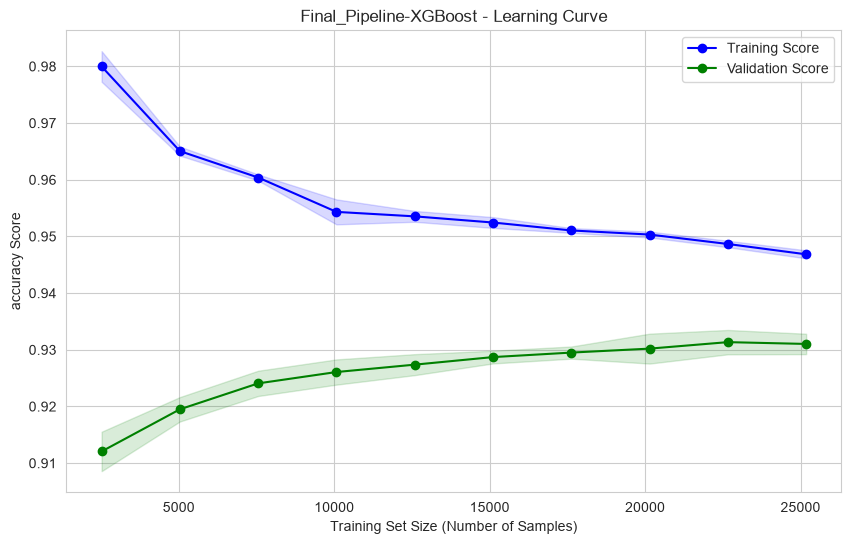

In [297]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X_tr, y_tr, title="Learning Curve"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_tr,
        y=y_tr,
        train_sizes=np.linspace(0.1, 1.0, 10),       # 10 steps from 10% to 100% data
        cv=5,                                        # Uses 5-fold CV internally
        scoring='accuracy',                          # Or 'neg_root_mean_squared_error'
        n_jobs=-1,
        random_state=42
    )

    # Calculate mean and standard deviation across folds
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    # 3. Plot the learning curves
    plt.figure(figsize=(10, 6))
    
    # Train Line
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

    # Validation Line
    plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

    plt.title(f"{title} - Learning Curve")
    plt.xlabel("Training Set Size (Number of Samples)")
    plt.ylabel("accuracy Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_learning_curve(final_Pipeline, X_train, y_train, title="Final_Pipeline-XGBoost")

In [298]:
thresholds = [0.3, 0.4, 0.5, 0.6]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.3,0.7793,0.9039,0.8370
1,0.4,0.8401,0.8511,0.8456
2,0.5,0.8983,0.8003,0.8465
3,0.6,0.9318,0.7591,0.8366


# Understand Model

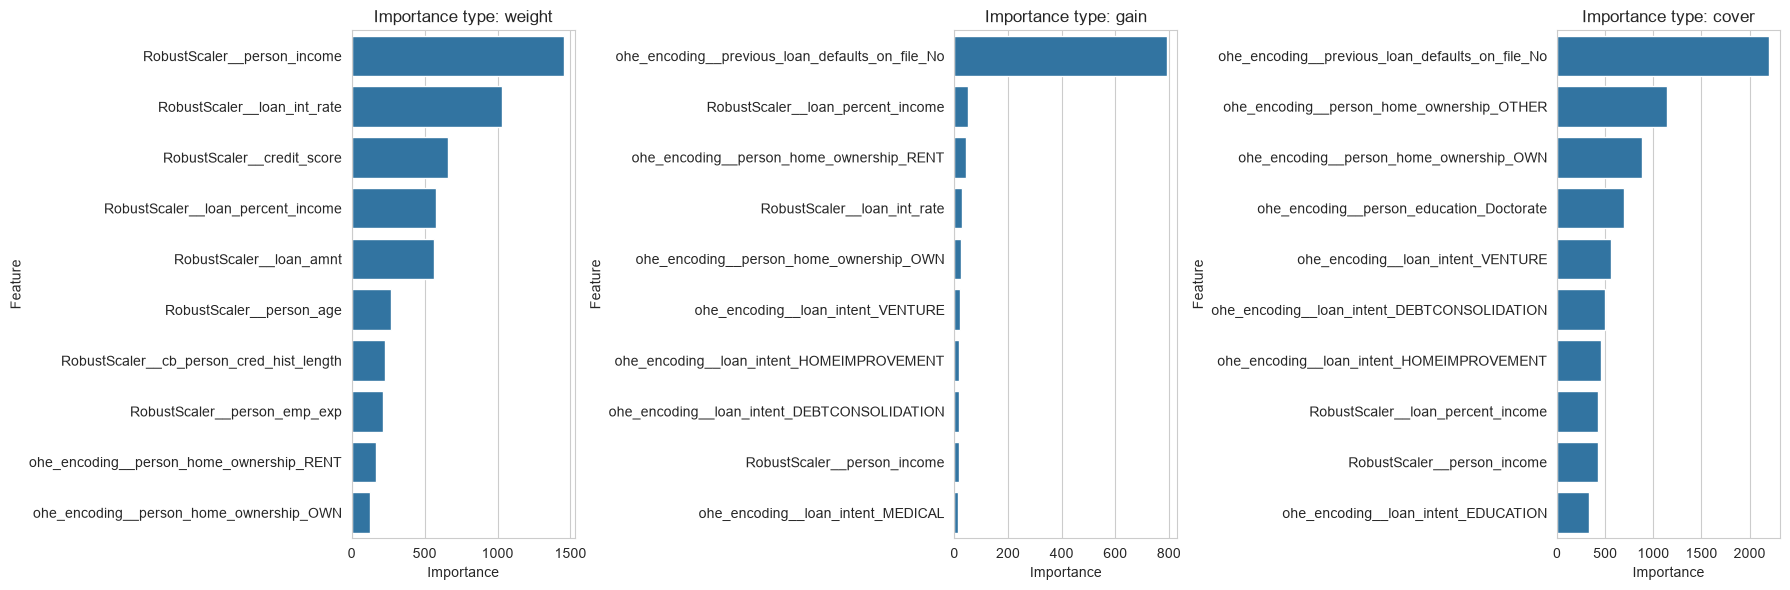

In [299]:
feature_names = final_Pipeline.named_steps["preprocessor"].get_feature_names_out()
booster = final_Pipeline.named_steps["Model"].get_booster()
booster.feature_names = list(feature_names)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp_type in zip(axes, ["weight", "gain", "cover"]):
    scores = booster.get_score(importance_type=imp_type)
    imp_df = (pd.DataFrame(scores.items(), columns=["Feature", "Importance"])
              .sort_values("Importance", ascending=False).head(10))
    sns.barplot(data=imp_df, x="Importance", y="Feature", ax=ax)
    ax.set_title(f"Importance type: {imp_type}")
plt.tight_layout()
plt.show()

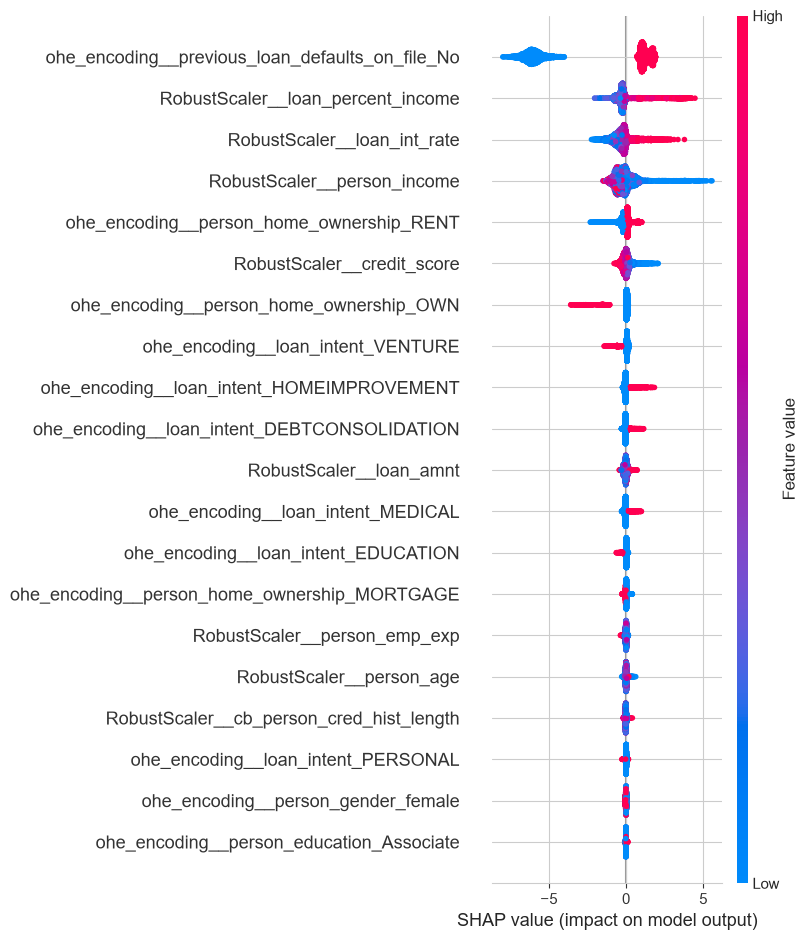

In [ ]:
import shap

X_test_transformed = final_Pipeline.named_steps["preprocessor"].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(final_Pipeline.named_steps["Model"])
shap_values = explainer.shap_values(X_test_transformed_df)

# Beeswarm - shows direction + magnitude per feature
shap.summary_plot(shap_values, X_test_transformed_df)


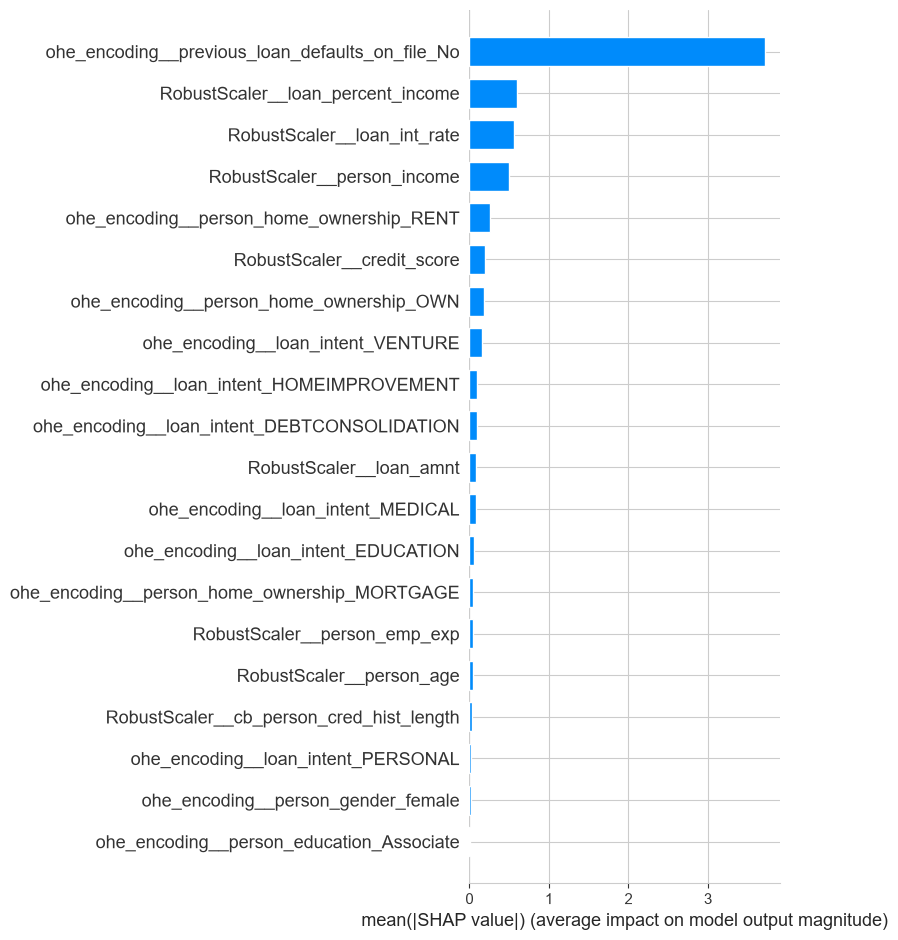

In [301]:
# Bar - mean |SHAP value|, a cleaner replacement for the built-in importance chart
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar")

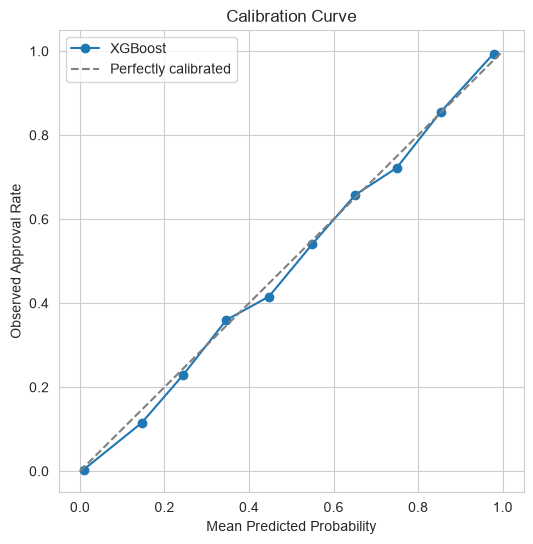

In [302]:
from sklearn.calibration import calibration_curve


y_test_proba = final_Pipeline.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Approval Rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

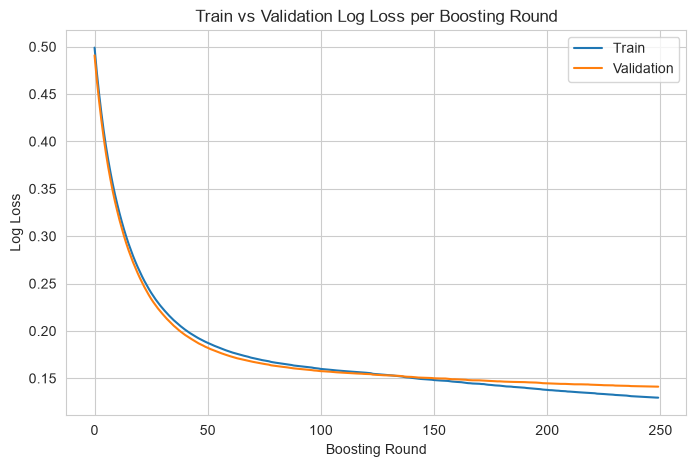

In [303]:
X_train_t = final_Pipeline.named_steps["preprocessor"].transform(X_train)
X_test_t = final_Pipeline.named_steps["preprocessor"].transform(X_test)
if hasattr(X_train_t, "toarray"):
    X_train_t = X_train_t.toarray()
    X_test_t = X_test_t.toarray()

# Rebuild with the same tuned hyperparameters found earlier, just to get eval_result curves
eval_model = XGBClassifier(**final_Pipeline.named_steps["Model"].get_params())
eval_model.fit(
    X_train_t, y_train,
    eval_set=[(X_train_t, y_train), (X_test_t, y_test)],
    verbose=False
)
results = eval_model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["logloss"], label="Train")
plt.plot(results["validation_1"]["logloss"], label="Validation")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Log Loss per Boosting Round")
plt.legend()
plt.show()

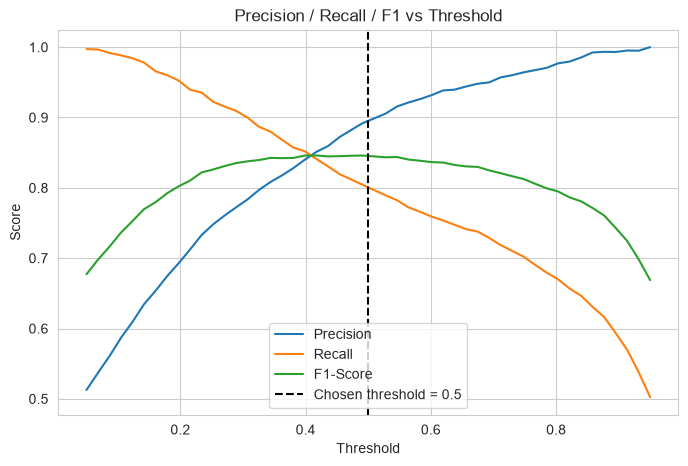

In [304]:
selected_threshold = 0.5

thresholds = np.linspace(0.05, 0.95, 50)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    pred_t = (y_test_proba >= t).astype(int)
    precisions.append(precision_score(y_test, pred_t, zero_division=0))
    recalls.append(recall_score(y_test, pred_t, zero_division=0))
    f1s.append(f1_score(y_test, pred_t, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1-Score")
plt.axvline(selected_threshold, color="black", linestyle="--", label=f"Chosen threshold = {selected_threshold}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.show()

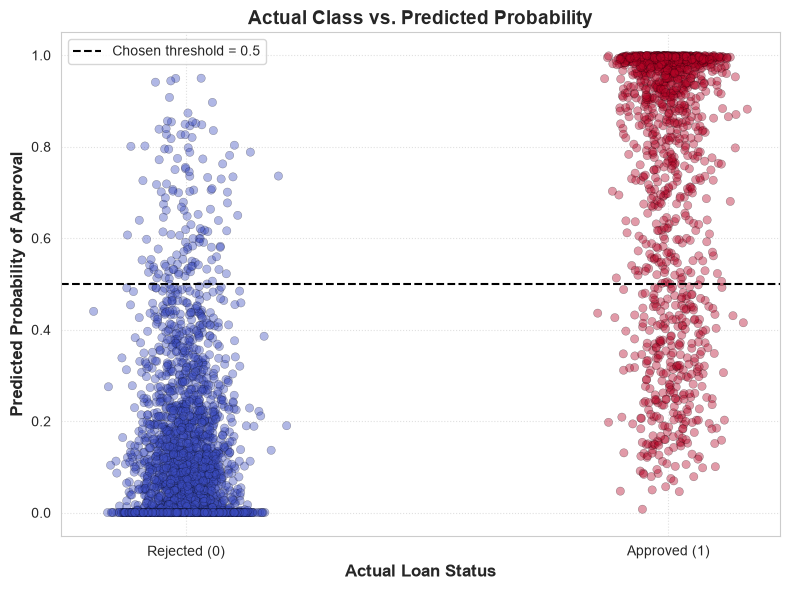

In [305]:
plt.figure(figsize=(8, 6))

# Jitter the x-position slightly so points at 0 and 1 don't fully overlap
jitter = np.random.normal(0, 0.05, size=len(y_test))

plt.scatter(
    y_test + jitter,
    y_test_proba,
    alpha=0.4,
    c=y_test,
    cmap="coolwarm",
    edgecolors="k",
    linewidth=0.3
)

# Show where the decision threshold cuts across
plt.axhline(selected_threshold, color="black", linestyle="--", linewidth=1.5,
            label=f"Chosen threshold = {selected_threshold}")

plt.xticks([0, 1], ["Rejected (0)", "Approved (1)"])
plt.xlabel("Actual Loan Status", fontsize=12, fontweight="bold")
plt.ylabel("Predicted Probability of Approval", fontsize=12, fontweight="bold")
plt.title("Actual Class vs. Predicted Probability", fontsize=14, fontweight="bold")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

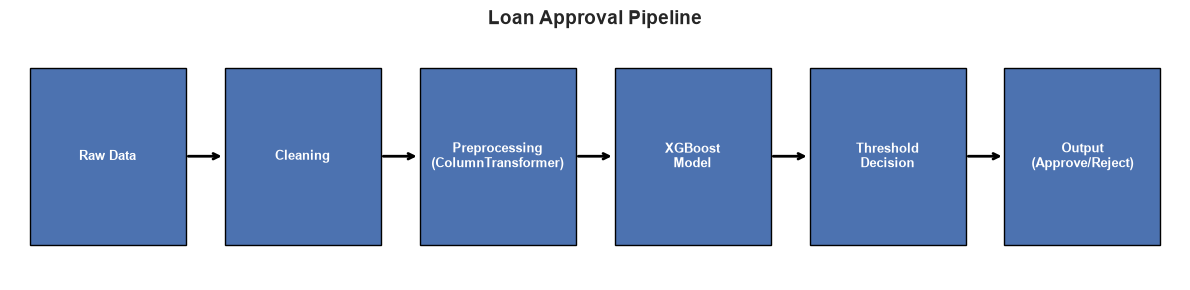

In [306]:
fig, ax = plt.subplots(figsize=(12, 3))
stages = ["Raw Data", "Cleaning", "Preprocessing\n(ColumnTransformer)", "XGBoost\nModel", "Threshold\nDecision", "Output\n(Approve/Reject)"]
x_positions = np.arange(len(stages))

for x, stage in zip(x_positions, stages):
    ax.add_patch(plt.Rectangle((x - 0.4, 0), 0.8, 1, facecolor="#4C72B0", edgecolor="black"))
    ax.text(x, 0.5, stage, ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    if x < len(stages) - 1:
        ax.annotate("", xy=(x + 0.6, 0.5), xytext=(x + 0.4, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=2, color="black"))

ax.set_xlim(-0.5, len(stages) - 0.5)
ax.set_ylim(-0.2, 1.2)
ax.axis("off")
plt.title("Loan Approval Pipeline", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Save The Model

In [307]:
import joblib

joblib.dump(final_Pipeline,'loan_model.pkl')

['loan_model.pkl']